## The Concept of Persistence in LangGraph


In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
from langgraph.checkpoint.memory import InMemorySaver

d:\dev\Tutorials\LangGraph\myenv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [4]:
load_dotenv()


True

In [5]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")


In [6]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [7]:
def generate_joke(state: JokeState):
    prompt = f"Generate a joke on the topic {state["topic"]}"
    response = llm.invoke(prompt).content
    return {'joke': response}
def generate_explanation(state: JokeState):
    prompt = f"Generate an explanation on the joke {state["joke"]}"
    response = llm.invoke(prompt).content
    return {'explanation': response}

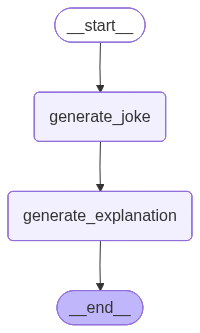

In [9]:
#graph
graph = StateGraph(JokeState)
graph.add_node('generate_joke',generate_joke)
graph.add_node('generate_explanation',generate_explanation)

graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','generate_explanation')
graph.add_edge('generate_explanation',END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)
workflow


In [10]:
config1 = {"configurable":{"thread_id": "1"}}
workflow.invoke({'topic':'pizza'},config=config1)


{'topic': 'pizza',
 'joke': 'Why did the pizza get a job?\n\nBecause it kneaded the dough!',
 'explanation': 'This joke is a classic example of a **pun**, which relies on words that sound alike but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" vs. "Needed":**\n    *   **Kneaded (pronounced "need-ed"):** This is a verb that describes the physical action of working dough with your hands, a crucial step in making pizza.\n    *   **Needed:** This is the past tense of "to need," meaning to require something.\n\n2.  **"Dough":**\n    *   **Dough (literal meaning):** The mixture of flour, water, and other ingredients that makes up the base of a pizza.\n    *   **Dough (slang meaning):** Money. People get jobs because they "need dough" (money).\n\n**The Humor:**\n\nThe joke plays on these double meanings.\n\n*   **From a pizza\'s perspective:** A pizza is made from dough, and the process often involves **kneading the dough**.\n*   **From a person\'s perspective (which t

In [11]:
workflow.get_state(config1)


StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a job?\n\nBecause it kneaded the dough!', 'explanation': 'This joke is a classic example of a **pun**, which relies on words that sound alike but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" vs. "Needed":**\n    *   **Kneaded (pronounced "need-ed"):** This is a verb that describes the physical action of working dough with your hands, a crucial step in making pizza.\n    *   **Needed:** This is the past tense of "to need," meaning to require something.\n\n2.  **"Dough":**\n    *   **Dough (literal meaning):** The mixture of flour, water, and other ingredients that makes up the base of a pizza.\n    *   **Dough (slang meaning):** Money. People get jobs because they "need dough" (money).\n\n**The Humor:**\n\nThe joke plays on these double meanings.\n\n*   **From a pizza\'s perspective:** A pizza is made from dough, and the process often involves **kneading the dough**.\n*   **From a person\'s p

In [12]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a job?\n\nBecause it kneaded the dough!', 'explanation': 'This joke is a classic example of a **pun**, which relies on words that sound alike but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" vs. "Needed":**\n    *   **Kneaded (pronounced "need-ed"):** This is a verb that describes the physical action of working dough with your hands, a crucial step in making pizza.\n    *   **Needed:** This is the past tense of "to need," meaning to require something.\n\n2.  **"Dough":**\n    *   **Dough (literal meaning):** The mixture of flour, water, and other ingredients that makes up the base of a pizza.\n    *   **Dough (slang meaning):** Money. People get jobs because they "need dough" (money).\n\n**The Humor:**\n\nThe joke plays on these double meanings.\n\n*   **From a pizza\'s perspective:** A pizza is made from dough, and the process often involves **kneading the dough**.\n*   **From a person\'s 

In [13]:
config2 = {"configurable":{"thread_id": "2"}}
workflow.invoke({'topic':'pasta'},config=config2)


{'topic': 'pasta',
 'joke': 'What do you call a fake noodle?\nAn impasta!',
 'explanation': 'This joke is a classic example of a **pun**!\n\nHere\'s why it\'s funny:\n\n1.  **"Imposter":** The joke plays on the word "imposter" (pronounced im-POS-ter), which refers to someone who pretends to be someone else, or something that is not genuine; a fake.\n2.  **"Pasta":** The word "pasta" (pronounced PAH-stuh) is the general term for noodles, which is exactly what the joke\'s setup is about ("noodle").\n3.  **The Pun:** The joke cleverly combines these by replacing the "ster" sound in "imposter" with "sta" from "pasta."\n\nSo, "impasta" sounds almost exactly like "imposter" (meaning fake), but it also clearly contains "pasta" (meaning noodle). The humor comes from the unexpected linguistic twist where a word meaning "fake" is blended with the food item in question, creating a new, humorous word that perfectly answers the question about a "fake noodle."'}

In [14]:
print(workflow.get_state(config1))
print(workflow.get_state(config2))

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza get a job?\n\nBecause it kneaded the dough!', 'explanation': 'This joke is a classic example of a **pun**, which relies on words that sound alike but have different meanings.\n\nHere\'s the breakdown:\n\n1.  **"Kneaded" vs. "Needed":**\n    *   **Kneaded (pronounced "need-ed"):** This is a verb that describes the physical action of working dough with your hands, a crucial step in making pizza.\n    *   **Needed:** This is the past tense of "to need," meaning to require something.\n\n2.  **"Dough":**\n    *   **Dough (literal meaning):** The mixture of flour, water, and other ingredients that makes up the base of a pizza.\n    *   **Dough (slang meaning):** Money. People get jobs because they "need dough" (money).\n\n**The Humor:**\n\nThe joke plays on these double meanings.\n\n*   **From a pizza\'s perspective:** A pizza is made from dough, and the process often involves **kneading the dough**.\n*   **From a person\'s p

## Time Travel


In [18]:
workflow.get_state({'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1167e4-1af4-6151-8000-a986c03a82a9'}}) # Every checkpoint has a corresponding checkpoint_id to it


StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1167e4-1af4-6151-8000-a986c03a82a9'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-03-02T21:24:54.889077+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1167e4-1af0-65ad-bfff-50c7663d2d5a'}}, tasks=(PregelTask(id='e613e613-5394-c51c-96bd-559c9c4e84c3', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza get a job?\n\nBecause it kneaded the dough!'}),), interrupts=())

In [19]:
workflow.invoke(None,{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1167e4-1af4-6151-8000-a986c03a82a9'}})


{'topic': 'pizza',
 'joke': 'Why did the pizza give such good advice?\n\nBecause it was a **wise slice**!',
 'explanation': 'The humor in "Why did the pizza give such good advice? Because it was a **wise slice**!" comes from a classic play on words, known as a pun.\n\nHere\'s the breakdown:\n\n1.  **The Pizza Connection:** A "slice" is the common term for a single piece of pizza. This sets up the literal context of the joke.\n2.  **The "Wise" Aspect:** The question states the pizza gave "good advice," which implies that the pizza itself was "wise" (having or showing experience, knowledge, and good judgment).\n3.  **The Pun:** The joke hinges on the phrase "**wise slice**" sounding almost identical to the idiom "**wise guy**."\n    *   A "wise guy" is an informal term for someone who is overly confident, thinks they are very clever, or makes sarcastic remarks. While often used negatively, the core implication is someone who is *perceived* as knowing a lot or being quick-witted.\n\nThe h

In [ ]:
list(workflow.get_state_history(config1))


[StateSnapshot(values={'topic': 'pizza', 'joke': "Why did the pizza chef get fired?\n\nBecause he kept making too many *mis-steaks* and couldn't *knead* the dough!"}, next=('generate_explanation',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f11664a-36c2-67ae-8001-d90da96eddfd'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-02T18:21:31.951075+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f116649-e7ec-6a1e-8000-7b88b736c0a4'}}, tasks=(PregelTask(id='243a97d6-0911-578a-7979-0bda25c2d3d1', name='generate_explanation', path=('__pregel_pull', 'generate_explanation'), error='ChatGoogleGenerativeAIError("Error calling model \'gemini-2.5-flash\' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {\'error\': {\'code\': 429, \'message\': \'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.de

## Updating State


In [25]:
workflow.update_state({'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1167e4-1af4-6151-8000-a986c03a82a9'}},{'topic':'samosa'})


{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f1167f3-f1b9-6c65-8001-304237433ff5'}}

In [26]:
list(workflow.get_state_history(config1))


[StateSnapshot(values={'topic': 'samosa'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1167f3-f1b9-6c65-8001-304237433ff5'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-03-02T21:32:00.062751+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f1167e4-1af4-6151-8000-a986c03a82a9'}}, tasks=(PregelTask(id='eb1ba159-83a1-0496-67fa-b59c837aad5e', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result=None),), interrupts=()),
 StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza give such good advice?\n\nBecause it was a **wise slice**!', 'explanation': 'The humor in "Why did the pizza give such good advice? Because it was a **wise slice**!" comes from a classic play on words, known as a pun.\n\nHere\'s the breakdown:\n\n1.  **The Pizza Connection:** A "slice" is the common term for a 

In [28]:
workflow.invoke(None,{'configurable': {'thread_id': '1', 'checkpoint_ns': '',  'checkpoint_id': '1f1167f3-f1b9-6c65-8001-304237433ff5'}})


{'topic': 'samosa',
 'joke': 'Why did the samosa get into therapy?\n\nBecause it had too many hidden *fillings*!',
 'explanation': 'This joke is a classic pun that plays on the similar-sounding words "fillings" and "feelings."\n\nHere\'s the breakdown:\n\n1.  **Samosa\'s "Fillings":** A samosa is a pastry snack that is literally *filled* with ingredients like spiced potatoes, peas, and other vegetables or meats. These contents are "hidden" inside its crispy outer shell.\n\n2.  **Therapy and "Feelings":** People go to therapy often because they have "hidden feelings" – unresolved emotions, anxieties, secrets, or past traumas – that they need to explore, understand, and process. They are "bottling up" or "hiding" their true emotions.\n\nThe humor comes from the **pun** where the samosa\'s literal characteristic (having *fillings* hidden inside) is swapped with the human reason for therapy (having *feelings* hidden inside). The punchline works because "fillings" sounds exactly like "feeli

## Fault Tolerance using Persistence


In [20]:
import time

# 1. Define the state
class CrashState(TypedDict):
    input: str
    step1: str
    step2: str
    step3: str

def step_1(state: CrashState) -> CrashState:
    print("✅ Step 1 executed")
    return {"step1": "done", "input": state["input"]}

def step_2(state: CrashState) -> CrashState:
    print("⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)")
    time.sleep(30)  # Simulate long-running hang
    return {"step2": "done"}

def step_3(state: CrashState) -> CrashState:
    print("✅ Step 3 executed")
    return {"step3": "done"}

In [21]:
builder = StateGraph(CrashState)
builder.add_node("step_1", step_1)
builder.add_node("step_2", step_2)
builder.add_node("step_3", step_3)

builder.add_edge(START, "step_1")
builder.add_edge("step_1", "step_2")
builder.add_edge("step_2", "step_3")
builder.add_edge("step_3", END)

checkpointer = InMemorySaver()

graph = builder.compile(checkpointer=checkpointer)

In [22]:
try:
    print("▶️ Running graph: Please manually interrupt during Step 2...")
    graph.invoke({"input": "start"}, config={"configurable": {"thread_id": 'thread-1'}})
except KeyboardInterrupt:
    print("❌ Kernel manually interrupted (crash simulated).")

▶️ Running graph: Please manually interrupt during Step 2...
✅ Step 1 executed
⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
❌ Kernel manually interrupted (crash simulated).


In [23]:
graph.get_state({"configurable": {"thread_id": 'thread-1'}})


StateSnapshot(values={'input': 'start', 'step1': 'done'}, next=('step_2',), config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1167ed-3682-6273-8001-c3e0e4119e1b'}}, metadata={'source': 'loop', 'step': 1, 'parents': {}}, created_at='2026-03-02T21:28:59.370326+00:00', parent_config={'configurable': {'thread_id': 'thread-1', 'checkpoint_ns': '', 'checkpoint_id': '1f1167ed-367d-666c-8000-af9dff9134f3'}}, tasks=(PregelTask(id='24e7258f-9163-dbce-182f-539a72571e8c', name='step_2', path=('__pregel_pull', 'step_2'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [24]:
# 6. Re-run to show fault-tolerant resume
final_state = graph.invoke(None, config={"configurable": {"thread_id": 'thread-1'}})
print("\n✅ Final State:", final_state)


⏳ Step 2 hanging... now manually interrupt from the notebook toolbar (STOP button)
✅ Step 3 executed

✅ Final State: {'input': 'start', 'step1': 'done', 'step2': 'done', 'step3': 'done'}
